In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 74.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/DATA_CLEAN"

images	labels


In [ ]:
!cp -r "/content/drive/MyDrive/DATA_CLEAN" /content/DATA_CLEAN
!ls /content/DATA_CLEAN

images	labels


In [ ]:
import re
import shutil
from pathlib import Path

DATA_ROOT = Path("/content/DATA_CLEAN")
IMAGES_DIR = DATA_ROOT / "images"
LABELS_DIR = DATA_ROOT / "labels"

# Handle possible double-nesting like images/images/
if (IMAGES_DIR / "images").exists():
    IMAGES_DIR = IMAGES_DIR / "images"
if (LABELS_DIR / "labels").exists():
    LABELS_DIR = LABELS_DIR / "labels"

print(f"Images from: {IMAGES_DIR}")
print(f"Labels from: {LABELS_DIR}")

# Regex to detect (N) suffix in filenames
img_dup = re.compile(r"\(\d+\)$")
lbl_dup = re.compile(r"\(\d+\)\.txt$")

# Find original (non-duplicate) files
image_files = list(IMAGES_DIR.glob("*.jpg"))
label_files = [f for f in LABELS_DIR.glob("*.txt") if not lbl_dup.search(f.name)]

# Use only unsuffixed image names; match against label stems
label_stems = {f.stem for f in label_files}
matched = []
seen = set()
for img in image_files:
    if img_dup.search(img.stem):
        continue  # skip (N) duplicates
    if img.stem in seen:
        continue
    if img.stem in label_stems:
        matched.append((img, LABELS_DIR / f"{img.stem}.txt"))
        seen.add(img.stem)

print(f"Matched image-label pairs: {len(matched)}")

# Build clean folder structure
CLEAN = Path("/content/clean")
if CLEAN.exists():
    shutil.rmtree(CLEAN)
(CLEAN / "images").mkdir(parents=True)
(CLEAN / "labels").mkdir(parents=True)

for img_path, label_path in matched:
    shutil.copy2(img_path, CLEAN / "images" / img_path.name)
    shutil.copy2(label_path, CLEAN / "labels" / label_path.name)

n_imgs = len(list((CLEAN / "images").iterdir()))
n_lbls = len(list((CLEAN / "labels").iterdir()))
print(f"Clean dataset built: {n_imgs} images, {n_lbls} labels")

Images from: /content/DATA_CLEAN/images
Labels from: /content/DATA_CLEAN/labels
Matched image-label pairs: 3327
Clean dataset built: 3327 images, 3327 labels


In [ ]:
# =========================================================
# DEBUG DATASET PATHS
# =========================================================

from pathlib import Path

DATA_ROOT = Path("/content/DATA_CLEAN")

print("DATA_ROOT exists:", DATA_ROOT.exists())

print("\nFolders inside DATA_ROOT:")
for x in DATA_ROOT.iterdir():
    print(x)

print("\nImages folder exists:", (DATA_ROOT / "images").exists())
print("Labels folder exists:", (DATA_ROOT / "labels").exists())

print("\nFirst few image files:")
images_dir = DATA_ROOT / "images"

all_files = list(images_dir.glob("*"))

print("Total files found:", len(all_files))

for f in all_files[:10]:
    print(f.name)

DATA_ROOT exists: True

Folders inside DATA_ROOT:
/content/DATA_CLEAN/labels
/content/DATA_CLEAN/images

Images folder exists: True
Labels folder exists: True

First few image files:
Total files found: 3327
48c7ab855d463fd8.jpg
4a042b5e4b52bd03.jpg
2467e4330ec685ba.jpg
132d7d40524dde19.jpg
cab625b13ed9b936.jpg
2baa0031df2b102e.jpg
077675c432e35399.jpg
1734a13088f697cf.jpg
c73cbaa279611683.jpg
2aff5fcb7130ff2e.jpg


Total images : 3327
Total labels : 3327
Images missing labels : 0
Labels missing images : 0

Class distribution:
Class 0: 3895


,class_id,count
0,0,3895


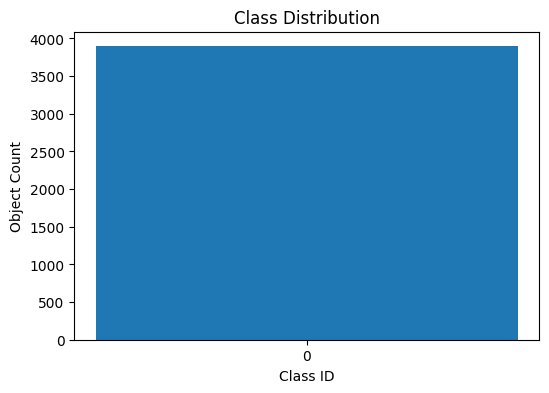


Image Width Statistics
Min Width  : 640
Max Width  : 5616
Mean Width : 2531.69

Image Height Statistics
Min Height  : 640
Max Height  : 5616
Mean Height : 1966.88


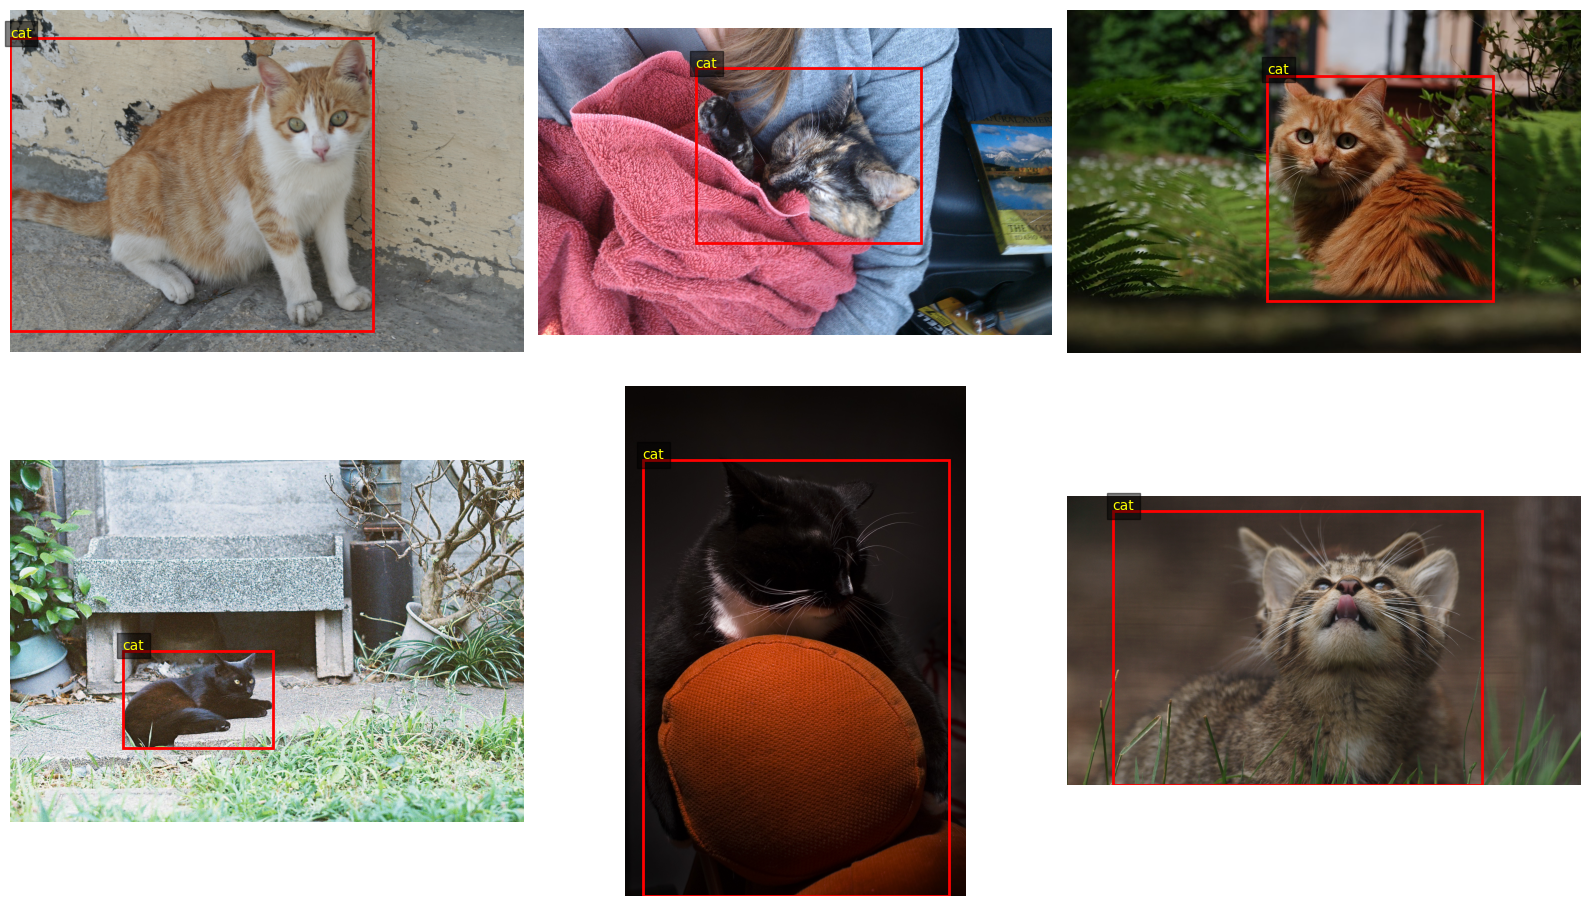

In [ ]:
# =========================================================
# TASK 1 — DATASET INSPECTION + VISUALISATION
# =========================================================

import random
from pathlib import Path
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

DATA_ROOT = Path("/content/clean")
IMAGES_DIR = DATA_ROOT / "images"
LABELS_DIR = DATA_ROOT / "labels"

# ---------------------------------------------------------
# Count images and labels
# ---------------------------------------------------------

# ---------------------------------------------------------
# Load all image files safely
# ---------------------------------------------------------

image_files = sorted(
    list(IMAGES_DIR.glob("*.jpg")) +
    list(IMAGES_DIR.glob("*.jpeg")) +
    list(IMAGES_DIR.glob("*.png")) +
    list(IMAGES_DIR.glob("*.JPG")) +
    list(IMAGES_DIR.glob("*.JPEG")) +
    list(IMAGES_DIR.glob("*.PNG"))
)

label_files = sorted(list(LABELS_DIR.glob("*.txt")))

print(f"Total images : {len(image_files)}")
print(f"Total labels : {len(label_files)}")

# ---------------------------------------------------------
# Check matching files
# ---------------------------------------------------------

image_stems = {f.stem for f in image_files}
label_stems = {f.stem for f in label_files}

missing_labels = image_stems - label_stems
missing_images = label_stems - image_stems

print(f"Images missing labels : {len(missing_labels)}")
print(f"Labels missing images : {len(missing_images)}")

# ---------------------------------------------------------
# Class distribution
# ---------------------------------------------------------

class_counter = Counter()

for label_path in label_files:
    with open(label_path) as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 5:
            class_id = int(parts[0])
            class_counter[class_id] += 1

print("\nClass distribution:")
for cls, count in class_counter.items():
    print(f"Class {cls}: {count}")

# ---------------------------------------------------------
# Display class distribution table
# ---------------------------------------------------------

df_classes = pd.DataFrame({
    "class_id": list(class_counter.keys()),
    "count": list(class_counter.values())
})

display(df_classes)

# ---------------------------------------------------------
# Plot class distribution
# ---------------------------------------------------------

plt.figure(figsize=(6,4))
plt.bar(df_classes["class_id"].astype(str), df_classes["count"])
plt.xlabel("Class ID")
plt.ylabel("Object Count")
plt.title("Class Distribution")
plt.show()

# ---------------------------------------------------------
# Image size statistics
# ---------------------------------------------------------

sample_images = random.sample(image_files, min(100, len(image_files)))

widths = []
heights = []

for img_path in sample_images:
    img = Image.open(img_path)
    w, h = img.size
    widths.append(w)
    heights.append(h)

print("\nImage Width Statistics")
print(f"Min Width  : {min(widths)}")
print(f"Max Width  : {max(widths)}")
print(f"Mean Width : {np.mean(widths):.2f}")

print("\nImage Height Statistics")
print(f"Min Height  : {min(heights)}")
print(f"Max Height  : {max(heights)}")
print(f"Mean Height : {np.mean(heights):.2f}")

# ---------------------------------------------------------
# Class names
# ---------------------------------------------------------

CLASS_NAMES = {
    0: "cat"
}

# ---------------------------------------------------------
# Visualise 6 random images with bounding boxes
# ---------------------------------------------------------

def draw_yolo_boxes(ax, image_path, label_path):
    img = Image.open(image_path).convert("RGB")
    w, h = img.size

    ax.imshow(img)
    ax.set_axis_off()

    if not label_path.exists():
        return

    with open(label_path) as f:
        lines = f.readlines()

    for line in lines:
        cls, cx, cy, bw, bh = map(float, line.strip().split())

        # Convert YOLO -> pixel coords
        x1 = (cx - bw/2) * w
        y1 = (cy - bh/2) * h
        box_w = bw * w
        box_h = bh * h

        rect = patches.Rectangle(
            (x1, y1),
            box_w,
            box_h,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )

        ax.add_patch(rect)

        ax.text(
            x1,
            y1 - 5,
            CLASS_NAMES.get(int(cls), str(int(cls))),
            color='yellow',
            fontsize=10,
            bbox=dict(facecolor='black', alpha=0.5)
        )

random_images = random.sample(image_files, 6)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, img_path in zip(axes.flatten(), random_images):
    lbl_path = LABELS_DIR / f"{img_path.stem}.txt"
    draw_yolo_boxes(ax, img_path, lbl_path)

plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# TASK 2 — TRAIN / VAL / TEST SPLITS
# =========================================================

import random
from pathlib import Path

random.seed(42)

DATA_ROOT = Path("/content/clean")
IMAGES_DIR = DATA_ROOT / "images"

all_images = sorted(list(IMAGES_DIR.glob("*.jpg")))

random.shuffle(all_images)

n = len(all_images)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

train_imgs = all_images[:train_end]
val_imgs = all_images[train_end:val_end]
test_imgs = all_images[val_end:]

print(f"Train: {len(train_imgs)}")
print(f"Val  : {len(val_imgs)}")
print(f"Test : {len(test_imgs)}")

# ---------------------------------------------------------
# Write split txt files
# ---------------------------------------------------------

def write_split(file_path, image_list):
    with open(file_path, "w") as f:
        for img in image_list:
            f.write(str(img.resolve()) + "\n")

write_split(DATA_ROOT / "train.txt", train_imgs)
write_split(DATA_ROOT / "val.txt", val_imgs)
write_split(DATA_ROOT / "test.txt", test_imgs)

print("Split text files created.")

Train: 2328
Val  : 499
Test : 500
Split text files created.


In [8]:
# =========================================================
# CREATE data.yaml
# =========================================================

yaml_text = """
path: /content/clean

train: train.txt
val: val.txt
test: test.txt

names:
  0: cat
"""

with open("/content/data.yaml", "w") as f:
    f.write(yaml_text)

print("data.yaml created.")

# Display file
with open("/content/data.yaml") as f:
    print(f.read())

data.yaml created.

path: /content/clean

train: train.txt
val: val.txt
test: test.txt

names:
  0: cat



In [9]:
!pip install ultralytics -q

In [ ]:
# Create folder for negative images
!mkdir -p /content/negative_images

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 000V0GBM2JC2.jpg to 000V0GBM2JC2.jpg
Saving 0.png to 0.png
Saving 0BRJ2QS8NILZ.jpg to 0BRJ2QS8NILZ.jpg
Saving 0CJL3C06KS1T.jpg to 0CJL3C06KS1T.jpg
Saving 0CVKXTN0L7DT.jpg to 0CVKXTN0L7DT.jpg
Saving 0E28A402D6C4.jpg to 0E28A402D6C4.jpg
Saving 0GUVWMREMWKN.jpg to 0GUVWMREMWKN.jpg
Saving 0H8GRJ59Z8FJ.jpg to 0H8GRJ59Z8FJ.jpg
Saving 0KVOE7U3EHA1.jpg to 0KVOE7U3EHA1.jpg
Saving 0LR38HR39B7O.jpg to 0LR38HR39B7O.jpg
Saving 0LR38HR39B7O_aug.jpg to 0LR38HR39B7O_aug.jpg
Saving 0MFXLCCY0469.jpg to 0MFXLCCY0469.jpg
Saving 0PRMJX9HLNJ6.jpg to 0PRMJX9HLNJ6.jpg
Saving 0TXSYGQH68CU.jpg to 0TXSYGQH68CU.jpg
Saving 0U5Z7XMG7Y39.jpg to 0U5Z7XMG7Y39.jpg
Saving 0U07Q7554CKO.jpg to 0U07Q7554CKO.jpg
Saving 0U07Q7554CKO_aug.jpg to 0U07Q7554CKO_aug.jpg
Saving 0VLQBM5FHA7P.jpg to 0VLQBM5FHA7P.jpg
Saving 0X2R9PDM51Q3.jpg to 0X2R9PDM51Q3.jpg
Saving 0XRVUXY0RKYW.jpg to 0XRVUXY0RKYW.jpg
Saving 0Z8IPXX3D986.jpg to 0Z8IPXX3D986.jpg
Saving 0ZIVQPUVUTIX.jpg to 0ZIVQPUVUTIX.jpg
Saving 0ZVO8GSV22V2.jpg to 0ZVO8GSV22V

In [ ]:
import shutil
from pathlib import Path

NEG_DIR = Path("/content/negative_images")

for filename in uploaded.keys():
    shutil.move(filename, NEG_DIR / filename)

print("Negative images moved.")

Negative images moved.


In [ ]:
from pathlib import Path
import shutil

DATA_IMAGES = Path("/content/clean/images")
DATA_LABELS = Path("/content/clean/labels")
NEG_DIR = Path("/content/negative_images")

negative_imgs = list(NEG_DIR.glob("*"))

count = 0

for img_path in negative_imgs:

    # Copy image
    shutil.copy(img_path, DATA_IMAGES / img_path.name)

    # Create EMPTY label file
    empty_label = DATA_LABELS / f"{img_path.stem}.txt"

    empty_label.touch()

    count += 1

print(f"Added {count} negative images.")

Added 2581 negative images.


In [ ]:
import random
from pathlib import Path

random.seed(42)

DATA_ROOT = Path("/content/clean")
IMAGES_DIR = DATA_ROOT / "images"

all_images = sorted(list(IMAGES_DIR.glob("*")))

# Keep only image files
all_images = [
    x for x in all_images
    if x.suffix.lower() in [".jpg", ".jpeg", ".png"]
]

random.shuffle(all_images)

n = len(all_images)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

train_imgs = all_images[:train_end]
val_imgs = all_images[train_end:val_end]
test_imgs = all_images[val_end:]

print(f"Train: {len(train_imgs)}")
print(f"Val  : {len(val_imgs)}")
print(f"Test : {len(test_imgs)}")

# Write split files
def write_split(file_path, image_list):
    with open(file_path, "w") as f:
        for img in image_list:
            f.write(str(img.resolve()) + "\n")

write_split(DATA_ROOT / "train.txt", train_imgs)
write_split(DATA_ROOT / "val.txt", val_imgs)
write_split(DATA_ROOT / "test.txt", test_imgs)

print("New splits created.")

Train: 4134
Val  : 886
Test : 887
New splits created.


# Updated Dataset with Negative Samples

To reduce false positives, additional negative samples were added to the dataset. These included 2581 images of dogs, rabbits, foxes, and other non-cat animals. Each negative image was paired with an empty YOLO label file, which tells YOLO that no cats are present in those images.

This helps the detector learn the difference between cats and visually similar animals instead of treating every furry animal as a cat.

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26s.pt")

results = model.train(
    data="/content/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project="/content/runs",
    name="cats_v2",
    seed=42
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, i

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/runs

ls: cannot access '/content/runs': No such file or directory


In [ ]:
!ls /content/runs/cats_v2/weights

ls: cannot access '/content/runs/cats_v2/weights': No such file or directory


In [ ]:
!cp /content/runs/cats_v2/weights/best.pt "/content/drive/MyDrive/best.pt"

cp: cannot stat '/content/runs/cats_v2/weights/best.pt': No such file or directory


# Training Results

The model was trained for 50 epochs using pretrained COCO weights. Validation metrics improved steadily during training, and the addition of negative samples reduced the number of false-positive detections on dogs and other animals.

The validation mAP increased over time while the training losses decreased consistently, indicating that the model successfully learned the custom dataset.

In [2]:
from ultralytics import YOLO

best_model = YOLO("/content/runs/cats_v2/weights/best.pt")

ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Plains_Zebra_Equus_quagga_cropped.jpg to Plains_Zebra_Equus_quagga_cropped.jpg


In [ ]:
results = best_model.predict(
    "Plains_Zebra_Equus_quagga_cropped.jpg",
    conf=0.50,
    save=True
)


image 1/1 /content/Plains_Zebra_Equus_quagga_cropped.jpg: 640x512 (no detections), 66.3ms
Speed: 7.1ms preprocess, 66.3ms inference, 3.8ms postprocess per image at shape (1, 3, 640, 512)
Results saved to /content/runs/detect/predict


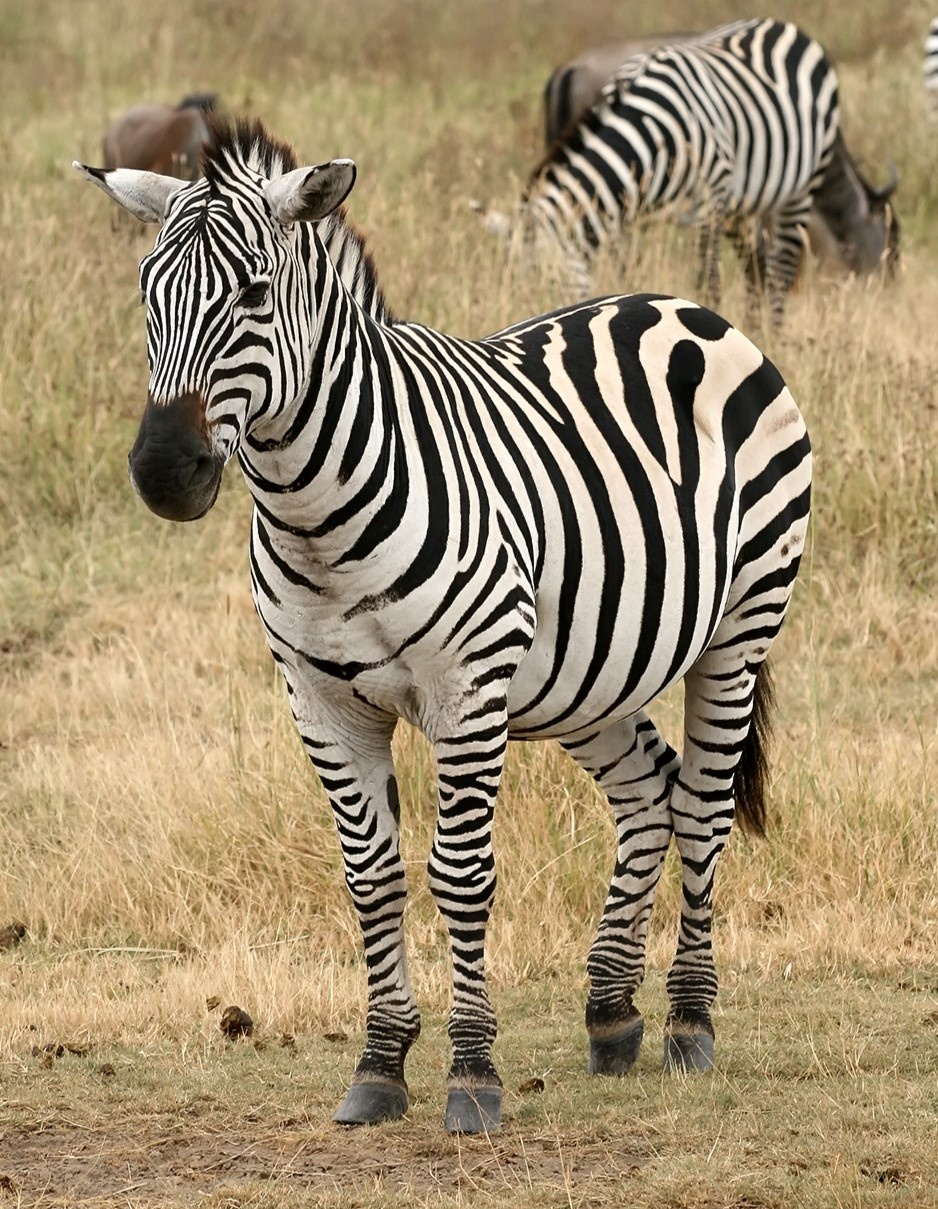

In [ ]:
from IPython.display import Image, display

display(Image(filename="/content/runs/detect/predict/Plains_Zebra_Equus_quagga_cropped.jpg"))

here, we checked our model's accuracy on a dog picture, and as you can see, it didn't detect any

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from ultralytics import YOLO

best_model = YOLO("/content/drive/MyDrive/best.pt")

ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
results = best_model.predict(
    source="/content/drive/MyDrive/cat-detection",
    conf=0.50,
    save=True
)

NameError: name 'best_model' is not defined

In [ ]:
from IPython.display import Image, display

display(Image(filename="/content/runs/detect/predict/360_F_418068474_VIWD3loz21dusicbe43VnAsAc9uZudyF.jpg"))

And here, we are looking at one of the biggest problems most of us struggled with- even though our model now can differentiate cats from other animals, it doesnn't work accurately when there is another animal in the photo.
But as you can see, My Model can do it, because of the large amount of pictures I used in the negative sampling.

In [ ]:
!find /content/drive/MyDrive -name "*.pt"

/content/drive/MyDrive/best.pt


In [4]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 73.8 MB/s eta 0:00:00


In [11]:
from ultralytics import YOLO

best_model = YOLO("/content/drive/MyDrive/best.pt")

In [ ]:
results = best_model.predict(
    source="/content/drive/MyDrive/cat-detection",
    conf=0.50,
    save=True
)


image 1/31 /content/drive/MyDrive/cat-detection/001.jpg: 384x640 (no detections), 2588.9ms
image 2/31 /content/drive/MyDrive/cat-detection/002.jpg: 448x640 (no detections), 2163.4ms
image 3/31 /content/drive/MyDrive/cat-detection/003.webp: 640x640 (no detections), 1277.3ms
image 4/31 /content/drive/MyDrive/cat-detection/004.jpg: 640x512 1 cat, 404.3ms
image 5/31 /content/drive/MyDrive/cat-detection/005.jpg: 640x448 1 cat, 345.8ms
image 6/31 /content/drive/MyDrive/cat-detection/006.jpg: 416x640 (no detections), 316.9ms
image 7/31 /content/drive/MyDrive/cat-detection/007.jpg: 448x640 (no detections), 310.6ms
image 8/31 /content/drive/MyDrive/cat-detection/008.jpg: 384x640 (no detections), 277.0ms
image 9/31 /content/drive/MyDrive/cat-detection/009.jpg: 640x640 (no detections), 442.6ms
image 10/31 /content/drive/MyDrive/cat-detection/010.jpg: 448x640 1 cat, 478.8ms
image 11/31 /content/drive/MyDrive/cat-detection/011.jpg: 320x640 1 cat, 369.9ms
image 12/31 /content/drive/MyDrive/cat-dete

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Path where YOLO saved predictions
pred_dir = "/content/runs/detect/predict"

# If multiple prediction folders exist, use latest one
if not os.path.exists(pred_dir):
    detect_dir = "/content/runs/detect"
    latest = sorted(os.listdir(detect_dir))[-1]
    pred_dir = os.path.join(detect_dir, latest)

print("Showing results from:", pred_dir)

# Get images
images = [
    img for img in os.listdir(pred_dir)
    if img.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Total images:", len(images))

# Display images
num_images = min(20, len(images))

fig, axes = plt.subplots(4, 5, figsize=(18, 14))

for ax, img_name in zip(axes.flatten(), images[:num_images]):

    img_path = os.path.join(pred_dir, img_name)

    img = Image.open(img_path)

    ax.imshow(img)
    ax.set_title(img_name[:15], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

Showing results from: /content/runs/detect/predict
Total images: 31


In [12]:
metrics = best_model.val(data="data.yaml", split="test")

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,465,567 parameters, 0 gradients, 20.5 GFLOPs



FileNotFoundError: Dataset 'data.yaml' images not found, missing path '/content/clean/val.txt'
Note dataset download directory is '/content/datasets'. You can update this in '/root/.config/Ultralytics/settings.json'